# LISTA3

### Zadanie 2

Korzystając z metody akceptacji-odrzucenia, zaimplementuj generator liczb losowych z podanego rozkładu: 

**a)** Niech $X$ będzie dyskretną zmienną losową o rozkładzie:

$$P(X = 1) = 0.11, \qquad P(X = 2) = 0.12, \qquad P(X = 3) = 0.27, \qquad P(X = 4) = 0.19, \qquad P(X = 5) = 0.31$$

Jako rozkład pomocniczy wybierz rozkład jednostajny.

**b)** Wygeneruj zmienną losową $X$ z rozkładu $\Gamma(\alpha = 3, \theta = 2)$ o gęstości:

$$f(x) = \frac{1}{16}x^2 e^{-\frac{x}{2}}, \quad x > 0$$

Jako rozkład pomocniczy wybierz rozkład wykładniczy z odpowiednim parametrem. 

Pokaż, że algorytm działa poprawnie, porównując:
* dystrybuantę teoretyczną z empiryczną,
* histogram z gęstością teoretyczną,
* wykres kwantylowy,
* średnią i wariancję teoretyczną z empiryczną.

Generowanie 10000 zmiennych dyskretnych...


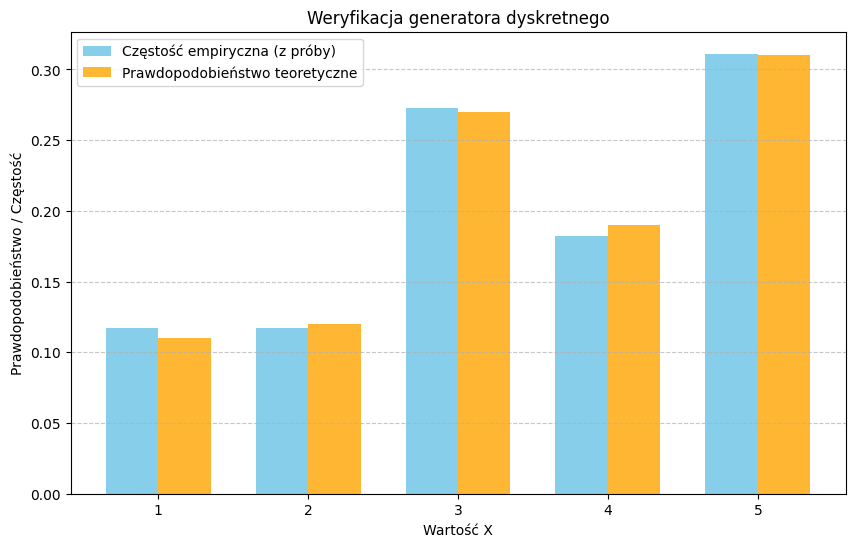


=== Porównanie parametrów (Dyskretne) ===
Średnia teoretyczna:   3.4700
Średnia empiryczna:    3.4522
--------------------------------------
Wariancja teoretyczna: 1.7691
Wariancja empiryczna:  1.8085


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

def generuj_zmienna_dyskretna():
    p = {1: 0.11, 2: 0.12, 3: 0.27, 4: 0.19, 5: 0.31}
    q =1/len(p)
    max_p = max(p.values())
    c = max_p / q

    while True:
        U = np.random.uniform(0,1)
        Y = np.random.choice([1, 2, 3, 4, 5])
        #U = np.random.uniform(0, 1)
        if U<=p[Y]/(c*q):
            return Y
 

# ==========================================
# WERYFIKACJA DLA ZMIENNEJ DYSKRETNEJ
# ==========================================
if __name__ == "__main__":
    N = 10000
    probka_dyskretna = np.array([generuj_zmienna_dyskretna() for _ in range(N)])

    # Parametry teoretyczne
    wartosci = np.array([1, 2, 3, 4, 5])
    prawdopodobienstwa = np.array([0.11, 0.12, 0.27, 0.19, 0.31])
    
    srednia_teoretyczna = np.sum(wartosci * prawdopodobienstwa)
    wariancja_teoretyczna = np.sum((wartosci**2) * prawdopodobienstwa) - srednia_teoretyczna**2

    # Obliczenie częstości empirycznych (ile razy wypadła dana liczba / N)
    czestosci_empiryczne = [np.sum(probka_dyskretna == v) / N for v in wartosci]

    # --- Wykres ---
    plt.figure(figsize=(10, 6))
    szerokosc = 0.35
    
    plt.bar(wartosci - szerokosc/2, czestosci_empiryczne, szerokosc, label='Częstość empiryczna (z próby)', color='skyblue')
    plt.bar(wartosci + szerokosc/2, prawdopodobienstwa, szerokosc, label='Prawdopodobieństwo teoretyczne', color='orange', alpha=0.8)
    
    plt.title('Weryfikacja generatora dyskretnego')
    plt.xlabel('Wartość X')
    plt.ylabel('Prawdopodobieństwo / Częstość')
    plt.xticks(wartosci)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # --- Wydruk statystyk ---
    print("\n=== Porównanie parametrów ===")
    print(f"Średnia teoretyczna:   {srednia_teoretyczna:.4f}")
    print(f"Średnia empiryczna:    {np.mean(probka_dyskretna):.4f}")
    print("-" * 38)
    print(f"Wariancja teoretyczna: {wariancja_teoretyczna:.4f}")
    print(f"Wariancja empiryczna:  {np.var(probka_dyskretna):.4f}")

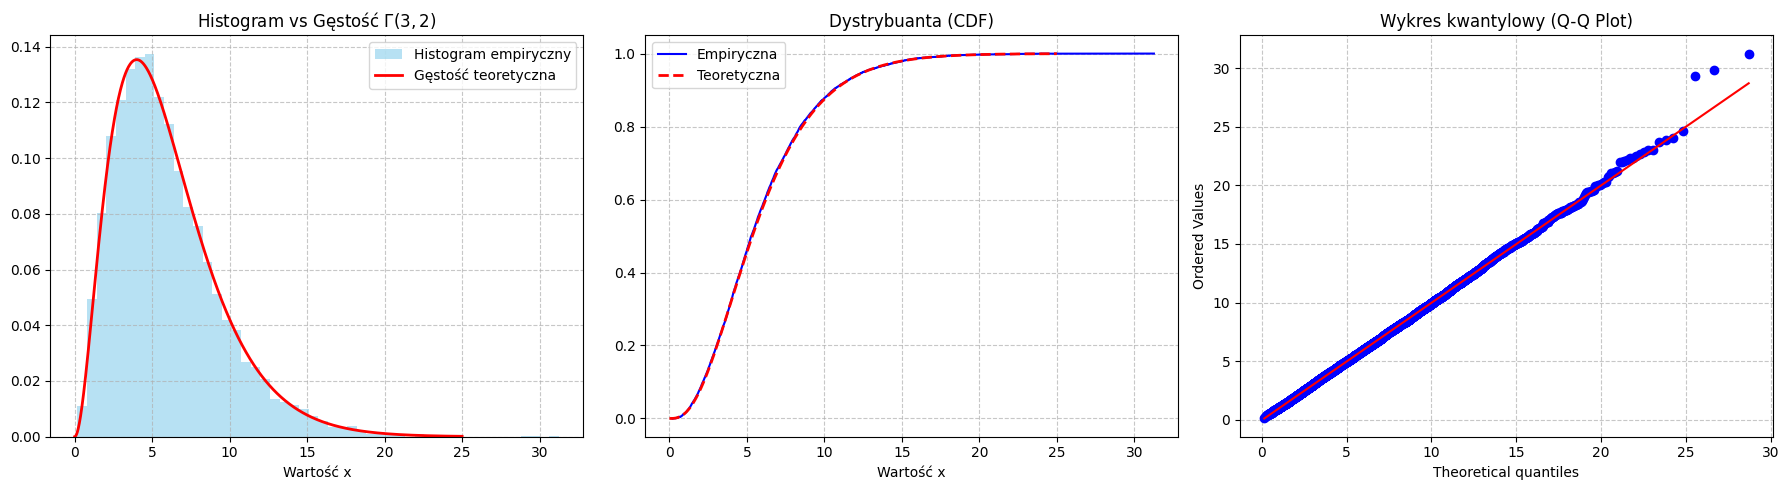


=== Porównanie parametrów (Ciągłe) ===
Średnia teoretyczna:   6.0000
Średnia empiryczna:    5.9620
--------------------------------------
Wariancja teoretyczna: 12.0000
Wariancja empiryczna:  12.0555


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generuj_zmienna_ciagla():
    c = 27/(2*np.exp(2))

    while True:
        U = np.random.uniform(0,1)
        Y = np.random.exponential(scale=6) #lambda=1/6

        f_Y = (1/16)*(Y**2)*np.exp(-Y/2) # Rozkład docelowy (Gamma)
        g_Y = (1/6) * np.exp(-Y/6) # Rozkład pomocniczy (Wykładniczy z parametrem lambda = 1/6)

        if U<=f_Y/(c*g_Y):
            return Y

# ==========================================
# WERYFIKACJA DLA ZMIENNEJ CIĄGŁEJ
# ==========================================
if __name__ == "__main__":
    N = 10000
    probka_ciagla = np.array([generuj_zmienna_ciagla() for _ in range(N)])

    # Konfiguracja rozkładu Gamma z scipy (alfa=3, theta=2)
    alfa = 3
    theta = 2
    rozklad_gamma = stats.gamma(a=alfa, scale=theta)

    # Przygotowanie wykresów
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # --- 1. Histogram z gęstością teoretyczną ---
    x_vals = np.linspace(0, 25, 1000)
    axs[0].hist(probka_ciagla, bins=50, density=True, alpha=0.6, color='skyblue', label='Histogram empiryczny')
    axs[0].plot(x_vals, rozklad_gamma.pdf(x_vals), 'r-', lw=2, label='Gęstość teoretyczna')
    axs[0].set_title(r'Histogram vs Gęstość $\Gamma(3, 2)$')
    axs[0].set_xlabel('Wartość x')
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.7)

    # --- 2. Dystrybuanta (empiryczna vs teoretyczna) ---
    x_sorted = np.sort(probka_ciagla)
    y_ecdf = np.arange(1, N + 1) / N
    axs[1].step(x_sorted, y_ecdf, label='Empiryczna', color='blue')
    axs[1].plot(x_vals, rozklad_gamma.cdf(x_vals), 'r--', lw=2, label='Teoretyczna')
    axs[1].set_title('Dystrybuanta (CDF)')
    axs[1].set_xlabel('Wartość x')
    axs[1].legend()
    axs[1].grid(True, linestyle='--', alpha=0.7)

    # --- 3. Wykres kwantylowy (Q-Q Plot) ---
    stats.probplot(probka_ciagla, dist=rozklad_gamma, plot=axs[2])
    axs[2].set_title('Wykres kwantylowy (Q-Q Plot)')
    axs[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # --- Wydruk statystyk ---
    srednia_teoretyczna = alfa * theta 
    wariancja_teoretyczna = alfa * (theta**2)

    print("\n=== Porównanie parametrów ===")
    print(f"Średnia teoretyczna:   {srednia_teoretyczna:.4f}")
    print(f"Średnia empiryczna:    {np.mean(probka_ciagla):.4f}")
    print("-" * 38)
    print(f"Wariancja teoretyczna: {wariancja_teoretyczna:.4f}")
    print(f"Wariancja empiryczna:  {np.var(probka_ciagla):.4f}")

## Zadanie 3

Korzystając z metody akceptacji-odrzucenia, zaimplementuj generator liczb losowych z rozkładu o podanej gęstości:

**a)** $f(x) = \frac{3}{2}(1 − x^2)$ na przedziale $[0,1].$

**b)** $f(x) = \frac{3}{2}sin(x)cos^2(x)$ na przedziale $[0,\pi].$

**c)** $f(x) = 2 {\sqrt{\frac{1}{2\pi}}} e^{-\frac{x^2}{2}}, \quad x \in \mathbb{R}^+$ (tzw. rozkład half-normal), za pomocą rozkładu wykładniczego.

Przedstaw te same wykresy co w zadaniu poprzednim.


## **a)**
### Wyznaczenie stałej $c$ 

**Dane wejściowe:**
* Funkcja docelowa: $f(x) = \frac{3}{2}(1 - x^2)$ dla $x \in [0, 1]$
* Funkcja pomocnicza: $g(x) = 1$ (gęstość rozkładu jednostajnego $U(0, 1)$)

Szukamy stałej $c$, zdefiniowanej jako:
$$c = \max_{x \in [0, 1]} \frac{f(x)}{g(x)} = \max_{x \in [0, 1]} \frac{\frac{3}{2}(1 - x^2)}{1} = \max_{x \in [0, 1]} \frac{3}{2}(1 - x^2)$$

#### 1. Analiza przebiegu funkcji
Aby znaleźć maksimum funkcji $f(x) = \frac{3}{2}(1 - x^2)$ na przedziale $[0, 1]$, sprawdzamy jej pochodną:
$$f'(x) = \frac{3}{2} \cdot (-2x) = -3x$$

#### 2. Wyznaczenie ekstremum
Przyrównujemy pochodną do zera:
$$-3x = 0 \implies x = 0$$

Sprawdzamy drugą pochodną, aby upewnić się, czy to maksimum:
$$f''(x) = -3$$
Ponieważ $f''(x) < 0$, w punkcie $x = 0$ funkcja osiąga lokalne maksimum.

#### 3. Obliczenie wartości maksymalnej
Podstawiamy $x = 0$ do wzoru funkcji $f(x)$:
$$f(0) = \frac{3}{2}(1 - 0^2) = \frac{3}{2} \cdot 1 = \frac{3}{2}$$

#### 4. Sprawdzenie granic przedziału
W metodzie akceptacji-odrzucenia na przedziale domkniętym zawsze sprawdzamy też wartości na końcach przedziału:
* Dla $x = 0$: $f(0) = 1.5$ (nasz kandydat na maksimum)
* Dla $x = 1$: $f(1) = \frac{3}{2}(1 - 1^2) = 0$

#### 5. Ostateczny wynik
Największą wartością stosunku $\frac{f(x)}{g(x)}$ na przedziale $[0, 1]$ jest wartość w punkcie $x = 0$.

Zatem ostateczna stała $c$ wynosi:
$$c = \frac{3}{2} = 1.5$$


### Liczenie dystrybuanty
Gęstość: $f(x) = \frac{3}{2}(1 - x^2)$ na przedziale $[0, 1]$.

Dolna granica to $0$. 

Liczymy całkę:$$F(x) = \int_{0}^{x} \frac{3}{2}(1 - t^2) dt$$
Najpierw wyciągamy stałą przed znak całki:$$F(x) = \frac{3}{2} \int_{0}^{x} (1 - t^2) dt$$
Całkujemy każdy element z osobna (całka z $1$ to $t$, całka z $t^2$ to $\frac{t^3}{3}$):$$F(x) = \frac{3}{2} \left[ t - \frac{t^3}{3} \right]_0^x$$
Podstawiamy górną granicę ($x$) i odejmujemy dolną ($0$):$$F(x) = \frac{3}{2} \left( x - \frac{x^3}{3} - (0 - 0) \right)$$
Mnożymy przez ułamek przed nawiasem i otrzymujemy gotowy wzór, którego użyliśmy w kodzie:$$F(x) = \frac{3}{2}x - \frac{1}{2}x^3$$

Generowanie 10000 zmiennych z rozkładu a)...


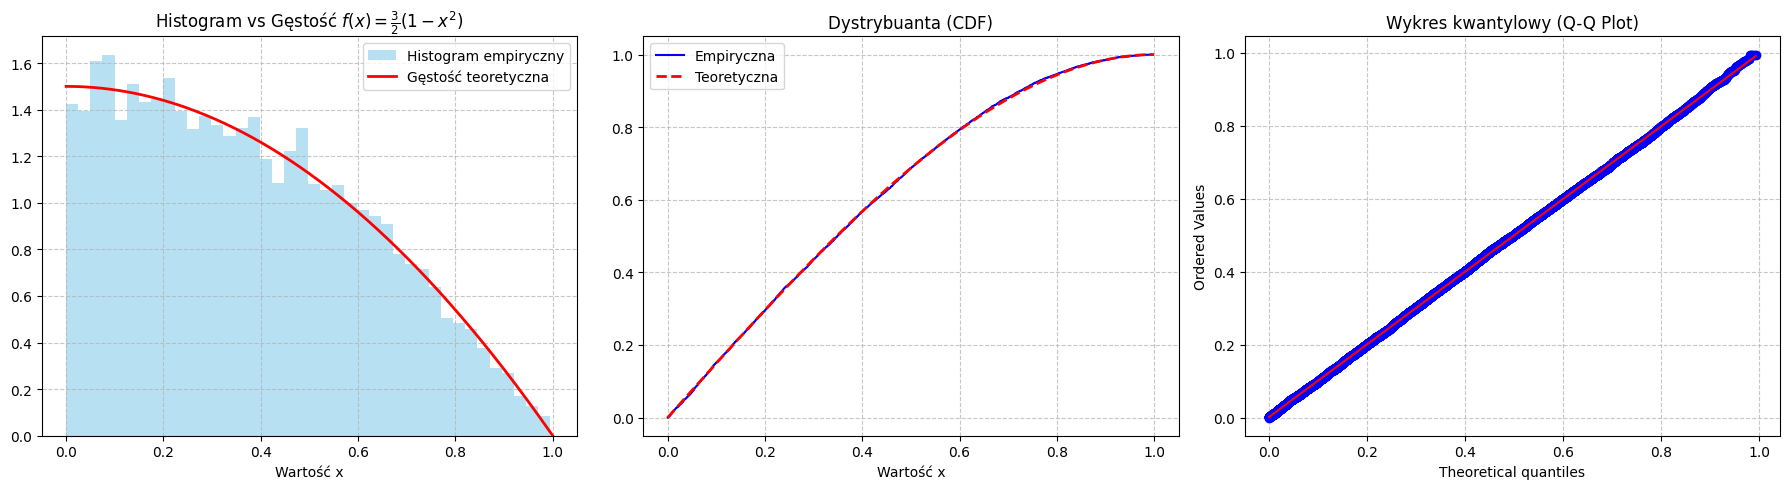


=== Porównanie parametrów rozkładu (Podpunkt a) ===
Średnia teoretyczna:   0.37500
Średnia empiryczna:    0.37497
------------------------------------------
Wariancja teoretyczna: 0.05938
Wariancja empiryczna:  0.05881


In [30]:
import numpy as np
import matplotlib.pyplot as plt

def gen_a():
    c = 1.5
    g_Y = 1 # gęstość U(0,1)
    
    while True: 
        U = np.random.uniform(0,1)
        Y = np.random.uniform(0,1)

        f_Y = 1.5*(1-Y**2)

        if U<=f_Y/(c*g_Y):
            return Y
        

# ==========================================
# CZĘŚĆ WIZUALIZACYJNA I WERYFIKACYJNA
# ==========================================

# 1. Definicja własnego rozkładu dla Scipy (żeby narysować Q-Q plot i CDF)
class rozklad_niestandardowy_a(stats.rv_continuous):
    def _pdf(self, x):
        return 1.5 * (1 - x**2)
    def _cdf(self, x):
        return 1.5 * x - 0.5 * (x**3)

if __name__ == "__main__":
    N = 10000
    print(f"Generowanie {N} zmiennych z rozkładu a)...")
    probka_a = np.array([gen_a() for _ in range(N)])

    # Inicjalizacja naszego rozkładu na przedziale określonym w zadaniu [0, 1]
    moj_rozklad = rozklad_niestandardowy_a(a=0, b=1, name='rozklad_a')

    # Przygotowanie obszaru na 3 wykresy
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    x_vals = np.linspace(0, 1, 1000) # Zmieniony zakres na [0, 1]

    # ---------------------------------------------------------
    # WYKRES 1: Histogram z gęstością teoretyczną
    # ---------------------------------------------------------
    axs[0].hist(probka_a, bins=40, density=True, alpha=0.6, color='skyblue', label='Histogram empiryczny')
    axs[0].plot(x_vals, moj_rozklad.pdf(x_vals), 'r-', lw=2, label='Gęstość teoretyczna')
    axs[0].set_title(r'Histogram vs Gęstość $f(x) = \frac{3}{2}(1-x^2)$')
    axs[0].set_xlabel('Wartość x')
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.7)

    # ---------------------------------------------------------
    # WYKRES 2: Dystrybuanta empiryczna vs teoretyczna
    # ---------------------------------------------------------
    x_sorted = np.sort(probka_a)
    y_ecdf = np.arange(1, N + 1) / N

    axs[1].step(x_sorted, y_ecdf, label='Empiryczna', color='blue')
    axs[1].plot(x_vals, moj_rozklad.cdf(x_vals), 'r--', lw=2, label='Teoretyczna')
    axs[1].set_title('Dystrybuanta (CDF)')
    axs[1].set_xlabel('Wartość x')
    axs[1].legend()
    axs[1].grid(True, linestyle='--', alpha=0.7)

    # ---------------------------------------------------------
    # WYKRES 3: Wykres kwantylowy (Q-Q plot)
    # ---------------------------------------------------------
    stats.probplot(probka_a, dist=moj_rozklad, plot=axs[2])
    axs[2].set_title('Wykres kwantylowy (Q-Q Plot)')
    axs[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # WERYFIKACJA NUMERYCZNA: Średnia i wariancja
    # ---------------------------------------------------------
    # Obliczone z całek: E[X] = całka z x*f(x), Var(X) = całka z x^2*f(x) - E[X]^2
    srednia_teoretyczna = 3/8          # czyli 0.375
    wariancja_teoretyczna = 1/5 - (3/8)**2 # czyli ~0.059375

    srednia_empiryczna = np.mean(probka_a)
    wariancja_empiryczna = np.var(probka_a)

    print("\n=== Porównanie parametrów rozkładu (Podpunkt a) ===")
    print(f"Średnia teoretyczna:   {srednia_teoretyczna:.5f}")
    print(f"Średnia empiryczna:    {srednia_empiryczna:.5f}")
    print("-" * 42)
    print(f"Wariancja teoretyczna: {wariancja_teoretyczna:.5f}")
    print(f"Wariancja empiryczna:  {wariancja_empiryczna:.5f}")

## **b)**
### Wyznaczenie stałej $c$ 

**Dane wejściowe:**
* Funkcja docelowa: $f(x) = \frac{3}{2}\sin(x)\cos^2(x)$ dla $x \in [0, \pi]$
* Funkcja pomocnicza: $g(x) = \frac{1}{\pi}$ (gęstość rozkładu jednostajnego $U(0, \pi)$)

Szukamy stałej $c$, która jest zdefiniowana jako:
$$c = \max_{x \in [0, \pi]} \frac{f(x)}{g(x)} = \max_{x \in [0, \pi]} \left( \frac{\frac{3}{2}\sin(x)\cos^2(x)}{\frac{1}{\pi}} \right) = \max_{x \in [0, \pi]} \left( \frac{3\pi}{2} \sin(x)\cos^2(x) \right)$$

Aby ułatwić obliczenia, wyciągamy stałą przed nawias i szukamy maksimum głównego trzonu funkcji:
$$h(x) = \sin(x)\cos^2(x)$$

#### 1. Obliczenie pochodnej $h'(x)$
Korzystamy ze wzoru na pochodną iloczynu: $(u \cdot v)' = u'v + uv'$.
$$h'(x) = (\sin(x))' \cdot \cos^2(x) + \sin(x) \cdot (\cos^2(x))'$$
$$h'(x) = \cos(x) \cdot \cos^2(x) + \sin(x) \cdot (-2\sin(x)\cos(x))$$
$$h'(x) = \cos^3(x) - 2\sin^2(x)\cos(x)$$

#### 2. Przyrównanie pochodnej do zera
Aby znaleźć ekstremum, rozwiązujemy równanie $h'(x) = 0$:
$$\cos^3(x) - 2\sin^2(x)\cos(x) = 0$$

Wyciągamy $\cos(x)$ przed nawias:
$$\cos(x) [\cos^2(x) - 2\sin^2(x)] = 0$$

Otrzymujemy dwa przypadki:
1. $\cos(x) = 0$ (Odrzucamy tę opcję, ponieważ daje to minimum funkcji $h(x) = 0$).
2. $\cos^2(x) - 2\sin^2(x) = 0$ (W tym miejscu znajduje się szukane maksimum).

#### 3. Wyznaczenie wartości w punkcie szczytowym
Z drugiego warunku otrzymujemy:
$$\cos^2(x) = 2\sin^2(x)$$

Korzystamy z jedynki trygonometrycznej ($\cos^2(x) = 1 - \sin^2(x)$) i podstawiamy do równania:
$$1 - \sin^2(x) = 2\sin^2(x)$$
$$1 = 3\sin^2(x)$$
$$\sin^2(x) = \frac{1}{3} \implies \sin(x) = \frac{1}{\sqrt{3}}$$
*(Wybieramy wartość dodatnią, ponieważ funkcja sinus przyjmuje wartości dodatnie na przedziale $x \in [0, \pi]$).*

Wracamy do równania na cosinus:
$$\cos^2(x) = 2\sin^2(x) = 2 \cdot \frac{1}{3} = \frac{2}{3}$$

#### 4. Podstawienie do ostatecznego wzoru na $c$
Wstawiamy wyliczone wartości z powrotem do głównego równania na $c$:
$$c = \frac{3\pi}{2} \cdot \left( \sin(x)\cos^2(x) \right)$$
$$c = \frac{3\pi}{2} \cdot \left( \frac{1}{\sqrt{3}} \cdot \frac{2}{3} \right)$$
$$c = \frac{3\pi}{2} \cdot \frac{2}{3\sqrt{3}}$$

Po skróceniu trójek i dwójek otrzymujemy ostateczny wynik analityczny:
$$c = \frac{\pi}{\sqrt{3}}$$


### Liczenie dystrybuanty
Gęstość: $f(x) = \frac{3}{2}\sin(x)\cos^2(x)$ na przedziale $[0, \pi]$.

Dolna granica to $0$. Liczymy całkę:$$F(x) = \int_{0}^{x} \frac{3}{2}\sin(t)\cos^2(t) dt$$
To klasyczny przykład całki, którą najłatwiej rozwiązać metodą przez podstawienie.

Niech $u = \cos(t)$.Wtedy pochodna $du = -\sin(t)dt$, z czego wynika, że $\sin(t)dt = -du$.
Podstawiamy to do naszej całki nieoznaczonej:$$\int \frac{3}{2} u^2 (-du) = -\frac{3}{2} \int u^2 du$$
Całka z $u^2$ to $\frac{u^3}{3}$:$$-\frac{3}{2} \cdot \frac{u^3}{3} = -\frac{1}{2}u^3$$
Wracamy do zmiennej $t$ (czyli $u = \cos(t)$):$$-\frac{1}{2}\cos^3(t)$$
Teraz podstawiamy granice całkowania (od $0$ do $x$):$$F(x) = \left[ -\frac{1}{2}\cos^3(t) \right]_0^x = \left(-\frac{1}{2}\cos^3(x)\right) - \left(-\frac{1}{2}\cos^3(0)\right)$$
Pamiętamy z trygonometrii, że $\cos(0) = 1$, więc $\cos^3(0) = 1^3 = 1$. 
Otrzymujemy ostateczny wzór:$$F(x) = -\frac{1}{2}\cos^3(x) - \left(-\frac{1}{2} \cdot 1\right) = -\frac{1}{2}\cos^3(x) + \frac{1}{2}$$
Po wyciągnięciu $0.5$ przed nawias, mamy wzór użyty w Pythonie:$$F(x) = \frac{1}{2}(1 - \cos^3(x))$$

Generowanie 10000 zmiennych z rozkładu b)...


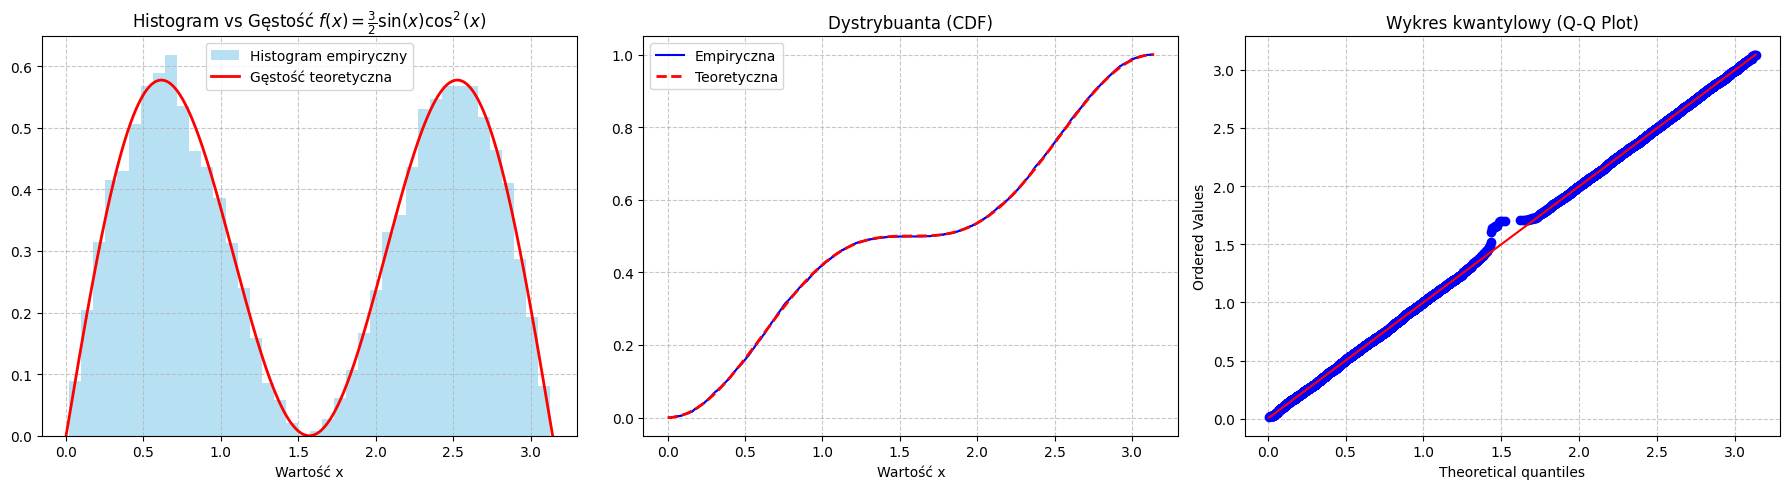


=== Porównanie parametrów rozkładu (Podpunkt b) ===
Średnia teoretyczna: 1.57080 (czyli pi/2)
Średnia empiryczna:  1.57037


In [40]:
import numpy as np
import matplotlib.pyplot as plt


def gen_b():
    c = np.pi/ np.sqrt(3)
    g_Y = 1/np.pi # Gęstość rozkładu U(0, pi)


    while True:
        U = np.random.uniform(0,1)
        Y = np.random.uniform(0,np.pi)

        f_Y = 1.5*np.sin(Y)*(np.cos(Y)**2)

        if U<=f_Y/(c*g_Y):
            return Y
        

# ==========================================
# CZĘŚĆ WIZUALIZACYJNA I WERYFIKACYJNA
# ==========================================

# 1. Definicja własnego rozkładu dla Scipy (Q-Q plot i CDF)
class rozklad_niestandardowy_b(stats.rv_continuous):
    def _pdf(self, x):
        return 1.5 * np.sin(x) * (np.cos(x)**2)
    def _cdf(self, x):
        # Całka z gęstości od 0 do x
        return 0.5 * (1 - np.cos(x)**3)

if __name__ == "__main__":
    N = 10000
    print(f"Generowanie {N} zmiennych z rozkładu b)...")
    probka_b = np.array([gen_b() for _ in range(N)])

    # Inicjalizacja naszego rozkładu na przedziale określonym w zadaniu [0, pi]
    moj_rozklad = rozklad_niestandardowy_b(a=0, b=np.pi, name='rozklad_b')

    # Przygotowanie obszaru na 3 wykresy
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    x_vals = np.linspace(0, np.pi, 1000)

    # ---------------------------------------------------------
    # WYKRES 1: Histogram z gęstością teoretyczną
    # ---------------------------------------------------------
    axs[0].hist(probka_b, bins=40, density=True, alpha=0.6, color='skyblue', label='Histogram empiryczny')
    axs[0].plot(x_vals, moj_rozklad.pdf(x_vals), 'r-', lw=2, label='Gęstość teoretyczna')
    axs[0].set_title(r'Histogram vs Gęstość $f(x) = \frac{3}{2}\sin(x)\cos^2(x)$')
    axs[0].set_xlabel('Wartość x')
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.7)

    # ---------------------------------------------------------
    # WYKRES 2: Dystrybuanta empiryczna vs teoretyczna
    # ---------------------------------------------------------
    x_sorted = np.sort(probka_b)
    y_ecdf = np.arange(1, N + 1) / N

    axs[1].step(x_sorted, y_ecdf, label='Empiryczna', color='blue')
    axs[1].plot(x_vals, moj_rozklad.cdf(x_vals), 'r--', lw=2, label='Teoretyczna')
    axs[1].set_title('Dystrybuanta (CDF)')
    axs[1].set_xlabel('Wartość x')
    axs[1].legend()
    axs[1].grid(True, linestyle='--', alpha=0.7)

    # ---------------------------------------------------------
    # WYKRES 3: Wykres kwantylowy (Q-Q plot)
    # ---------------------------------------------------------
    stats.probplot(probka_b, dist=moj_rozklad, plot=axs[2])
    axs[2].set_title('Wykres kwantylowy (Q-Q Plot)')
    axs[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # WERYFIKACJA NUMERYCZNA: Średnia
    # ---------------------------------------------------------
    # E[X] to całka z x * 1.5 * sin(x) * cos^2(x) od 0 do pi.
    # Wartość tej całki wynosi dokładnie pi/2.
    srednia_teoretyczna = np.pi / 2 
    srednia_empiryczna = np.mean(probka_b)

    print("\n=== Porównanie parametrów rozkładu (Podpunkt b) ===")
    print(f"Średnia teoretyczna: {srednia_teoretyczna:.5f} (czyli pi/2)")
    print(f"Średnia empiryczna:  {srednia_empiryczna:.5f}")

## **c)**
### Wyznaczenie stałej $c$ 

**Dane wejściowe:**
* Funkcja docelowa (half-normal): $f(x) = \sqrt{\frac{2}{\pi}} e^{-x^2/2}$ dla $x \ge 0$
* Funkcja pomocnicza (wykładnicza): $g(x) = \lambda e^{-\lambda x}$ dla $x \ge 0$

**1. Wybór parametru $\lambda$:**
Dla optymalizacji algorytmu przyjmujemy $\lambda = 1$, zatem $g(x) = e^{-x}$.

**2. Wyznaczenie stałej $c$:**
Szukamy maksimum stosunku:
$$\frac{f(x)}{g(x)} = \frac{\sqrt{2/\pi} e^{-x^2/2}}{e^{-x}} = \sqrt{\frac{2}{\pi}} e^{-x^2/2 + x}$$

Badamy funkcję w wykładniku $w(x) = -\frac{x^2}{2} + x$. 
Jej pochodna $w'(x) = -x + 1$ zeruje się dla $x = 1$. Jest to maksimum lokalne.

**3. Obliczenie wartości $c$:**
Podstawiamy $x = 1$ do wzoru na stosunek gęstości:
$$c = \sqrt{\frac{2}{\pi}} e^{-1/2 + 1} = \sqrt{\frac{2}{\pi}} e^{1/2} = \sqrt{\frac{2e}{\pi}}$$

Wartość przybliżona:
$$c \approx 1.3155$$






Generowanie 10000 zmiennych z rozkładu c) (half-normal)...


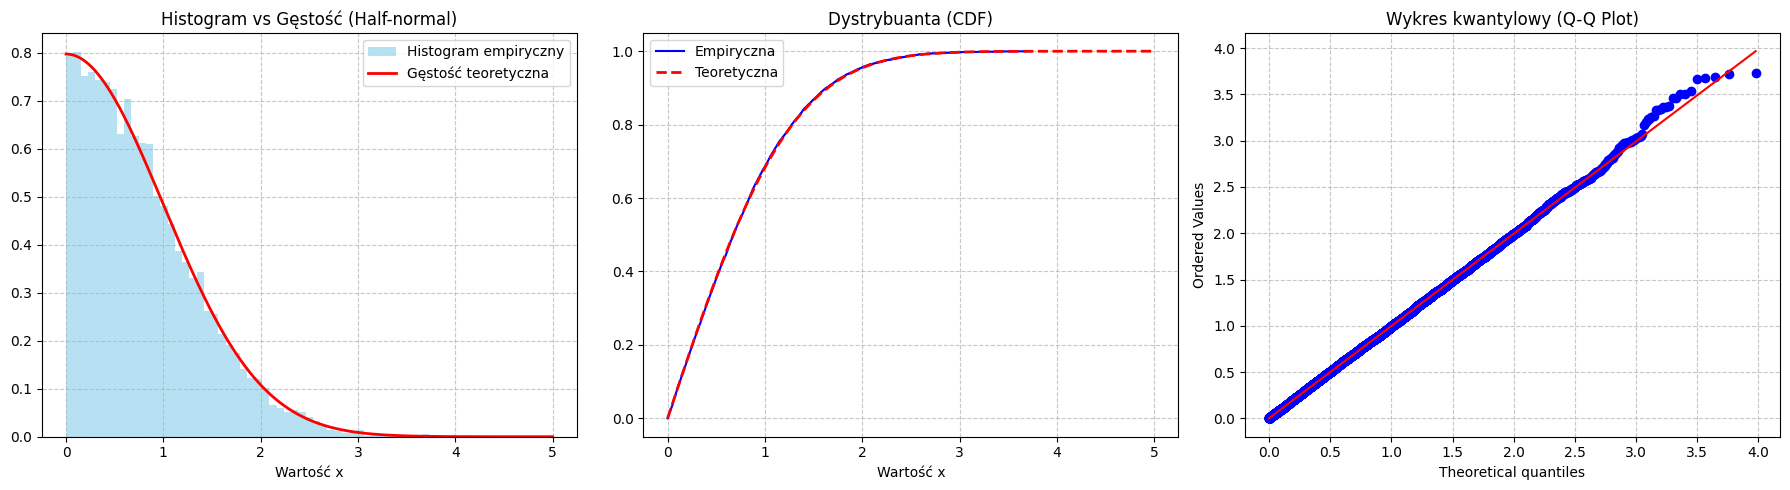


=== Porównanie parametrów rozkładu (Podpunkt c) ===
Średnia teoretyczna:   0.79788
Średnia empiryczna:    0.79689
------------------------------------------
Wariancja teoretyczna: 0.36338
Wariancja empiryczna:  0.36054


In [48]:
import numpy as np
import matplotlib.pyplot as plt


def gen_c():
    c = np.sqrt(2*np.exp(1)/np.pi)

    while True:
        U = np.random.uniform(0,1)
        Y = np.random.exponential(scale=1) #lambda=1

        f_Y = 2*np.sqrt(1/(2*np.pi))*np.exp(-Y**2/2)
        g_Y = np.exp(-Y) # to jest 1 * exp(-1 * Y)

        if U<=f_Y/(c*g_Y):
            return Y
        

# ==========================================
# CZĘŚĆ WIZUALIZACYJNA I WERYFIKACYJNA
# ==========================================
if __name__ == "__main__":
    N = 10000
    print(f"Generowanie {N} zmiennych z rozkładu c) (half-normal)...")
    probka_c = np.array([gen_c() for _ in range(N)])

    # W scipy istnieje gotowy rozkład half-normal!
    moj_rozklad = stats.halfnorm()

    # Przygotowanie obszaru na 3 wykresy
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    x_vals = np.linspace(0, 5, 1000) # rozkład jest dla x > 0, do 5 wystarczy by zobaczyć ogon

    # ---------------------------------------------------------
    # WYKRES 1: Histogram z gęstością teoretyczną
    # ---------------------------------------------------------
    axs[0].hist(probka_c, bins=50, density=True, alpha=0.6, color='skyblue', label='Histogram empiryczny')
    axs[0].plot(x_vals, moj_rozklad.pdf(x_vals), 'r-', lw=2, label='Gęstość teoretyczna')
    axs[0].set_title(r'Histogram vs Gęstość (Half-normal)')
    axs[0].set_xlabel('Wartość x')
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.7)

    # ---------------------------------------------------------
    # WYKRES 2: Dystrybuanta empiryczna vs teoretyczna
    # ---------------------------------------------------------
    x_sorted = np.sort(probka_c)
    y_ecdf = np.arange(1, N + 1) / N

    axs[1].step(x_sorted, y_ecdf, label='Empiryczna', color='blue')
    axs[1].plot(x_vals, moj_rozklad.cdf(x_vals), 'r--', lw=2, label='Teoretyczna')
    axs[1].set_title('Dystrybuanta (CDF)')
    axs[1].set_xlabel('Wartość x')
    axs[1].legend()
    axs[1].grid(True, linestyle='--', alpha=0.7)

    # ---------------------------------------------------------
    # WYKRES 3: Wykres kwantylowy (Q-Q plot)
    # ---------------------------------------------------------
    stats.probplot(probka_c, dist=moj_rozklad, plot=axs[2])
    axs[2].set_title('Wykres kwantylowy (Q-Q Plot)')
    axs[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # WERYFIKACJA NUMERYCZNA: Średnia i wariancja
    # ---------------------------------------------------------
    # Teoretyczne wzory dla standardowego half-normal:
    # E[X] = sqrt(2/pi)
    # Var(X) = 1 - 2/pi
    srednia_teoretyczna = np.sqrt(2 / np.pi)
    wariancja_teoretyczna = 1 - 2 / np.pi

    srednia_empiryczna = np.mean(probka_c)
    wariancja_empiryczna = np.var(probka_c)

    print("\n=== Porównanie parametrów rozkładu (Podpunkt c) ===")
    print(f"Średnia teoretyczna:   {srednia_teoretyczna:.5f}")
    print(f"Średnia empiryczna:    {srednia_empiryczna:.5f}")
    print("-" * 42)
    print(f"Wariancja teoretyczna: {wariancja_teoretyczna:.5f}")
    print(f"Wariancja empiryczna:  {wariancja_empiryczna:.5f}")

## Zadanie 4
Zaimplementuj metodę Boxa-Mullera generowania zmiennych losowych z rozkładu normalnego.

In [49]:
import numpy as np

def gen_box_muller():
    # Losujemy dwie zmienne z rozkładu jednostajnego (0,1)
    U_1 = np.random.uniform(0,1)
    U_2  =np.random.uniform(0,1)

    # Obliczamy zmienne o standardowym rozkładzie normalnym N(0,1)
    X = np.sqrt(-2*np.log(U_1))*np.cos(2*np.pi*U_2)
    Y = np.sqrt(-2*np.log(U_1))*np.sin(2*np.pi*U_2)
    return X, Y

# Test działania:
x_val, y_val = gen_box_muller()
print(f"Wygenerowane liczby: {x_val}, {y_val}")

Wygenerowane liczby: 0.022598528372301634, 0.28294099755804025


In [50]:
import numpy as np

def gen_box_muller_wektorowo(n):
    """
    Generuje 'n' liczb z rozkładu normalnego za pomocą metody Boxa-Mullera.
    """
    # Ponieważ metoda daje 2 wyniki na raz, potrzebujemy n/2 par
    n_par = (n + 1) // 2 
    
    # Generujemy od razu całe wektory wartości (tablice)
    U_1 = np.random.uniform(0, 1, n_par)
    U_2 = np.random.uniform(0, 1, n_par)

    X = np.sqrt(-2 * np.log(U_1)) * np.cos(2 * np.pi * U_2)
    Y = np.sqrt(-2 * np.log(U_1)) * np.sin(2 * np.pi * U_2)
    
    # Łączymy obie tablice X i Y w jedną
    wynik = np.concatenate((X, Y))
    
    # Jeśli n było nieparzyste, wygenerowaliśmy o jedną liczbę za dużo. 
    # Ucinamy tablicę do dokładnie n elementów.
    return wynik[:n]

# Test działania:
probki = gen_box_muller_wektorowo(10)
print("10 wygenerowanych liczb z rozkładu normalnego:")
print(probki)

10 wygenerowanych liczb z rozkładu normalnego:
[ 1.46434307  0.90030337 -0.12987131  0.79121193 -0.81427919  0.33578889
 -0.30802946 -1.14170667 -0.20725317 -0.7959888 ]


## Zadanie 5
Zaimplementuj metodę biegunową Boxa-Mullera. Przetestuj, która metoda działa
szybciej (biegunowa czy zwykła). Narysuj wykres czasu działania obu algorytmów
w zależności od liczby generowanych zmiennych.

In [51]:
import numpy as np

def gen_box_muller_biegunowa():
    while True:
        U_1 = np.random.uniform(-1,1)
        U_2  =np.random.uniform(-1,1)

        R2 = U_1**2+U_2**2
        if 0<R2<=1 :
            mnoznik = np.sqrt(-2*np.log(R2)/R2)
            X = U_1 * mnoznik 
            Y = U_2 * mnoznik
            return X, Y
        


 Liczba par (N) |  Zwykła metoda [s] | Metoda biegunowa [s] |
----------------------------------------------------------------------
           1000 |            0.01109 |              0.01334 |
           5000 |            0.06181 |              0.04232 |
          10000 |            0.10076 |              0.08320 |
          20000 |            0.20219 |              0.15791 |
          50000 |            0.54645 |              0.40297 |



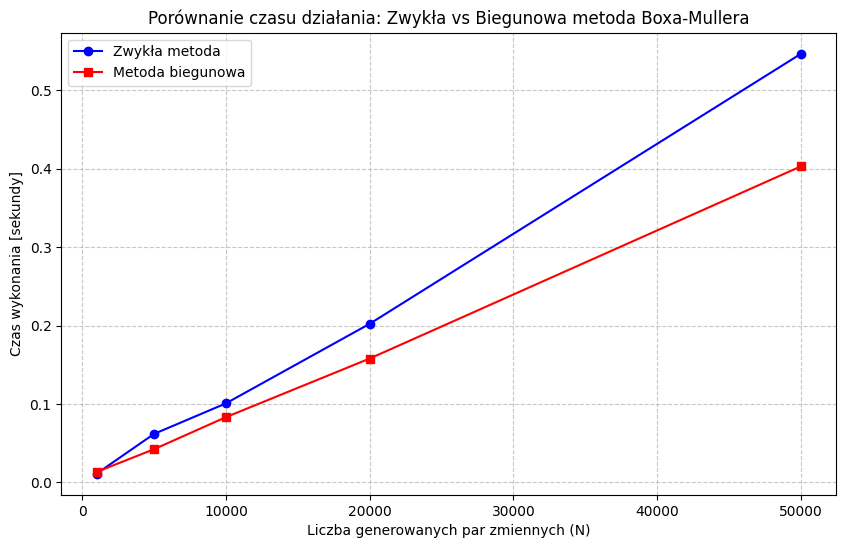

In [52]:
import numpy as np
import time
import matplotlib.pyplot as plt

def test_performance():
    N_values = [1000, 5000, 10000, 20000, 50000]
    
    times_standard = []
    times_polar = []
    
    for n in N_values:
        start_time = time.time()
        for _ in range(n):
            gen_box_muller()
        times_standard.append(time.time() - start_time)

        start_time = time.time()
        for _ in range(n):
            gen_box_muller_biegunowa()
        times_polar.append(time.time() - start_time)

    # --- Wypisywanie tabeli w konsoli ---
    print("\n" + "="*70)
    print(f"{'Liczba par (N)':>15} | {'Zwykła metoda [s]':>18} | {'Metoda biegunowa [s]':>20} |")
    print("-" * 70)
    for i in range(len(N_values)):
        print(f"{N_values[i]:>15} | {times_standard[i]:>18.5f} | {times_polar[i]:>20.5f} |")
    print("="*70 + "\n")

    # --- Rysowanie wykresu ---
    plt.figure(figsize=(10, 6))
    plt.plot(N_values, times_standard, label='Zwykła metoda', marker='o', color='blue')
    plt.plot(N_values, times_polar, label='Metoda biegunowa', marker='s', color='red')
    
    plt.xlabel('Liczba generowanych par zmiennych (N)')
    plt.ylabel('Czas wykonania [sekundy]')
    plt.title('Porównanie czasu działania: Zwykła vs Biegunowa metoda Boxa-Mullera')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()

if __name__ == "__main__":
    test_performance()

## Zadanie 6
Korzystając z dekompozycji Cholesky’ego, wygeneruj $N = 10^4$ wektorów normalnych dla macierzy kowariancji 2 × 2 z korelacją $ρ = 0.8$ oraz dla macierzy 3 × 3
z korelacjami $ρ_{12} = 0.7, ρ_{13} = −0.3, ρ_{23} = 0.4.$ Zwizualizuj wygenerowane rozkłady (wykresy punktowe par zmiennych).


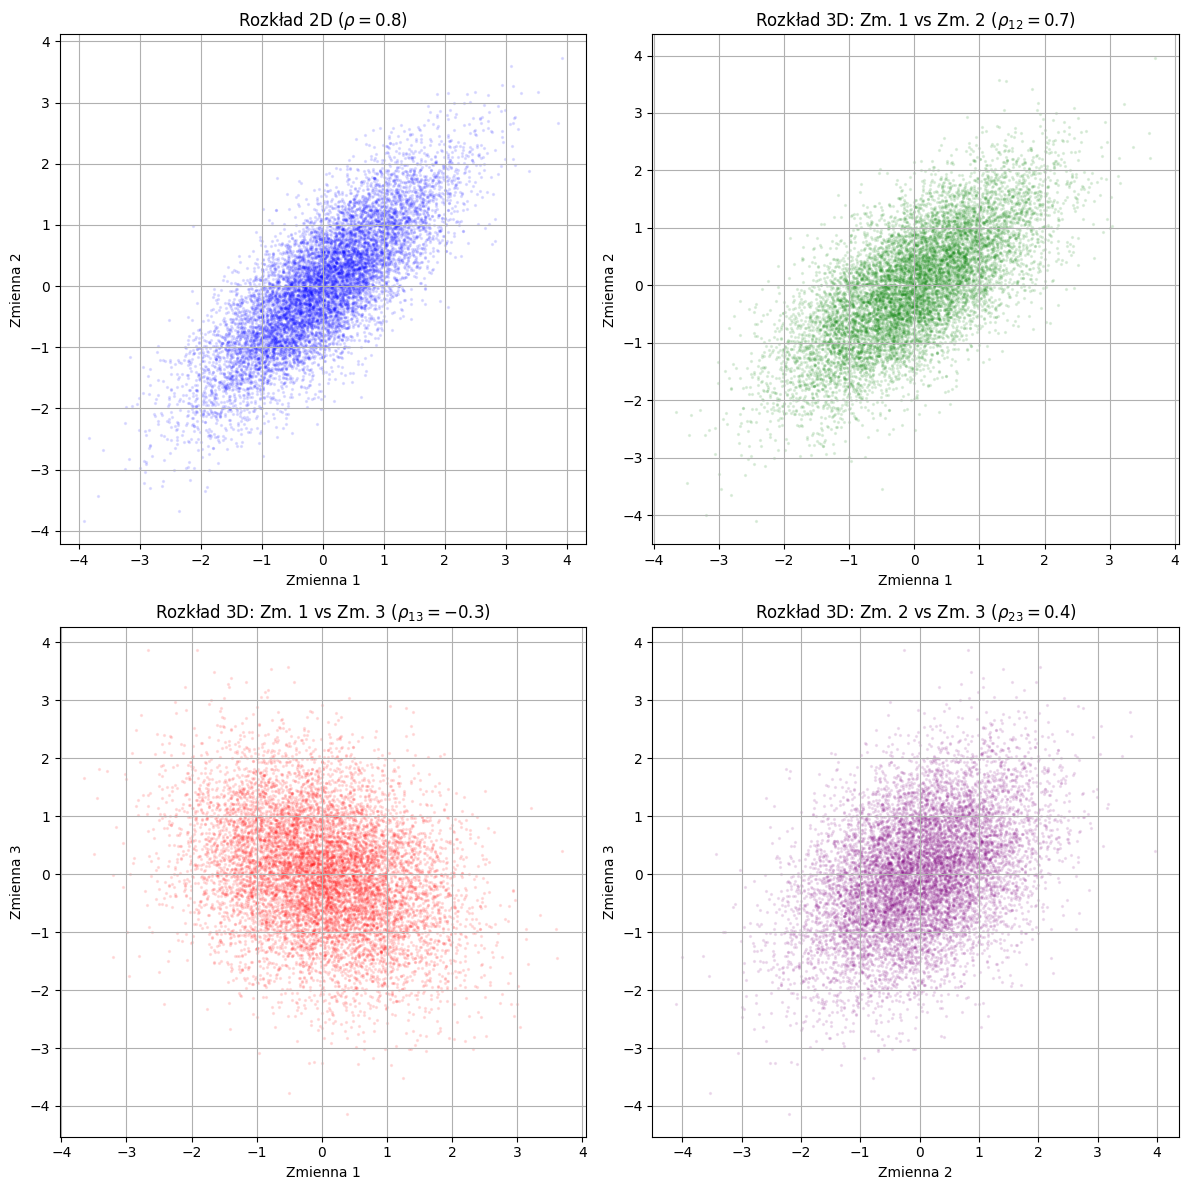

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Ustawienie ziarna losowości (opcjonalne, ale zapewnia powtarzalność wyników)
np.random.seed(42)

# Liczba wektorów do wygenerowania
N = 10000

# ==========================================
# CZĘŚĆ 1: Macierz 2x2 (korelacja p = 0.8)
# ==========================================

# Krok 1: Definiowanie macierzy kowariancji
Sigma_2 = np.array([[1.0, 0.8],
                    [0.8, 1.0]])

# Krok 2: Dekompozycja Cholesky'ego (Znajdujemy macierz L)
L_2 = np.linalg.cholesky(Sigma_2)

# Krok 3: Generowanie wektora Z (niezależne N(0,1))
# Wymiar to 2 wiersze i N kolumn
Z_2 = np.random.randn(2, N)

# Krok 4: Przekształcenie wektorów (X = LZ)
X_2 = L_2 @ Z_2

# ==========================================
# CZĘŚĆ 2: Macierz 3x3 (różne korelacje)
# ==========================================

# Krok 1: Definiowanie macierzy kowariancji
# p12 = 0.7, p13 = -0.3, p23 = 0.4
Sigma_3 = np.array([[ 1.0,  0.7, -0.3],
                    [ 0.7,  1.0,  0.4],
                    [-0.3,  0.4,  1.0]])

# Krok 2: Dekompozycja Cholesky'ego
L_3 = np.linalg.cholesky(Sigma_3)

# Krok 3: Generowanie wektora Z (wymiar 3 x N)
Z_3 = np.random.randn(3, N)

# Krok 4: Przekształcenie wektorów (X = LZ)
X_3 = L_3 @ Z_3 # @ - mnożenie macierzowe

# ==========================================
# CZĘŚĆ 3: Wizualizacja
# ==========================================

# Rysujemy 4 wykresy (jeden dla 2D, trzy dla 3D)
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

# 1. Wykres dla przypadku 2D
axs[0, 0].scatter(X_2[0, :], X_2[1, :], alpha=0.1, color='blue', s=2)
axs[0, 0].set_title('Rozkład 2D ($\\rho = 0.8$)')
axs[0, 0].set_xlabel('Zmienna 1')
axs[0, 0].set_ylabel('Zmienna 2')
axs[0, 0].grid(True)

# 2. Wykres dla przypadku 3D - Zmienna 1 vs Zmienna 2
axs[0, 1].scatter(X_3[0, :], X_3[1, :], alpha=0.1, color='green', s=2)
axs[0, 1].set_title('Rozkład 3D: Zm. 1 vs Zm. 2 ($\\rho_{12} = 0.7$)')
axs[0, 1].set_xlabel('Zmienna 1')
axs[0, 1].set_ylabel('Zmienna 2')
axs[0, 1].grid(True)

# 3. Wykres dla przypadku 3D - Zmienna 1 vs Zmienna 3
axs[1, 0].scatter(X_3[0, :], X_3[2, :], alpha=0.1, color='red', s=2)
axs[1, 0].set_title('Rozkład 3D: Zm. 1 vs Zm. 3 ($\\rho_{13} = -0.3$)')
axs[1, 0].set_xlabel('Zmienna 1')
axs[1, 0].set_ylabel('Zmienna 3')
axs[1, 0].grid(True)

# 4. Wykres dla przypadku 3D - Zmienna 2 vs Zmienna 3
axs[1, 1].scatter(X_3[1, :], X_3[2, :], alpha=0.1, color='purple', s=2)
axs[1, 1].set_title('Rozkład 3D: Zm. 2 vs Zm. 3 ($\\rho_{23} = 0.4$)')
axs[1, 1].set_xlabel('Zmienna 2')
axs[1, 1].set_ylabel('Zmienna 3')
axs[1, 1].grid(True)

# Dopasowanie układu i wyświetlenie
plt.tight_layout()
plt.show()

## Zadanie 7 – obliczanie całek metodą Monte Carlo
Metoda akceptacji-odrzucenia ma naturalne zastosowanie w przybliżonym obliczaniu całek (metoda trafień).

**a)** Oszacuj wartość $\pi$: losuj punkty $(x, y)$ z kwadratu $[-1, 1]^2$ i licz, jaka część wpada do koła $x^2 + y^2 \le 1$. Narysuj wykres zbieżności estymatora do $\pi$ w funkcji liczby prób.

**b)** Oszacuj całkę $\int_0^1 e^{-x^2} dx$ (nie ma wzoru w postaci zamkniętej). Porównaj wynik z $scipy.integrate.quad$.

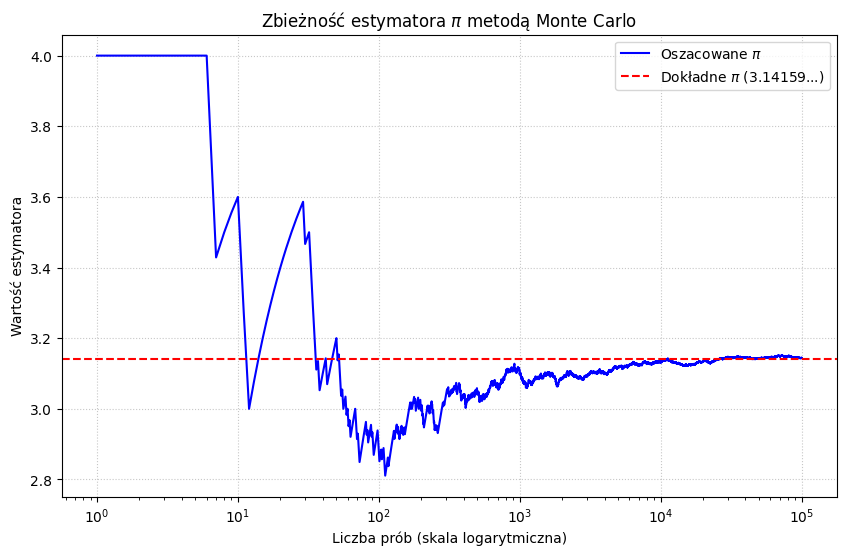

Ostateczne oszacowanie pi po 100000 próbach: 3.14412
Błąd bezwzględny: 0.00253


In [54]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def oszacuj_pi(N=100000):
    # Krok 1: Losowanie współrzędnych X i Y z przedziału [-1, 1]
    X = np.random.uniform(-1, 1, N)
    Y = np.random.uniform(-1, 1, N)
    
    # Krok 2: Sprawdzenie, które punkty trafiły do koła (X^2 + Y^2 <= 1)
    # Wynikiem jest tablica wartości True (trafił) i False (nie trafił)
    trafienia = (X**2 + Y**2) <= 1
    
    # Krok 3: Obliczanie przybliżenia pi "w locie"
    # np.cumsum liczy narastającą sumę trafień (ile jedynek uzbieraliśmy do danego momentu)
    suma_trafien = np.cumsum(trafienia)
    
    # Tworzymy tablicę numerów prób [1, 2, 3, ..., N] do dzielenia
    numery_prob = np.arange(1, N + 1)
    
    # Wzór: 4 * (trafienia w kole) / (wszystkie dotychczasowe rzuty)
    pi_estymowane = 4 * suma_trafien / numery_prob
    
    # Krok 4: Narysowanie wykresu zbieżności
    plt.figure(figsize=(10, 6))
    
    # Rysujemy nasz estymator
    plt.plot(numery_prob, pi_estymowane, color='blue', label=r'Oszacowane $\pi$')
    
    # Rysujemy poziomą linię z prawdziwą wartością pi dla odniesienia
    plt.axhline(y=np.pi, color='red', linestyle='--', label=r'Dokładne $\pi$ (3.14159...)')
    
    # Formatowanie wykresu
    plt.xscale('log') # Skala logarytmiczna osi X lepiej pokazuje początkowe wahania
    plt.xlabel('Liczba prób (skala logarytmiczna)')
    plt.ylabel('Wartość estymatora')
    plt.title(r'Zbieżność estymatora $\pi$ metodą Monte Carlo')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.show()
    
    # Zwrócenie ostatecznego wyniku z ostatniej próby
    print(f"Ostateczne oszacowanie pi po {N} próbach: {pi_estymowane[-1]:.5f}")
    print(f"Błąd bezwzględny: {abs(pi_estymowane[-1] - np.pi):.5f}")

# Uruchomienie funkcji
oszacuj_pi(100000)

--- Wyniki dla N = 10000 próbek ---
Oszacowana całka (Monte Carlo): 0.751000
Dokładna całka (SciPy):         0.746824
Błąd bezwzględny:               0.004176


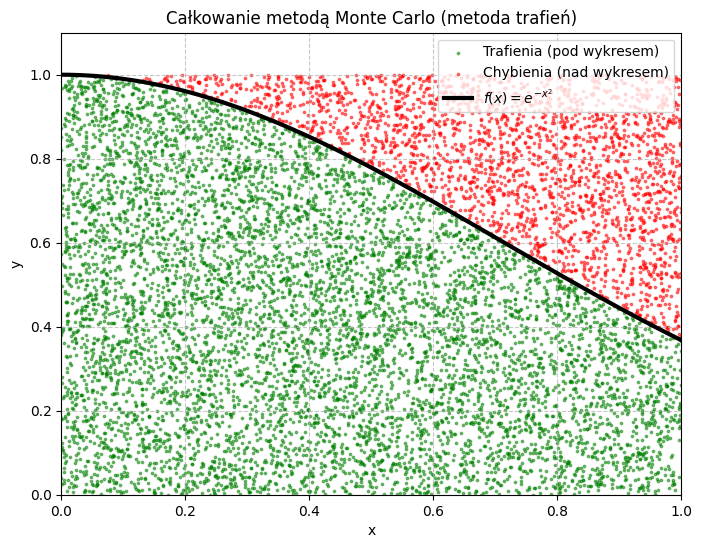

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

def zadanie_7b(N=10000):
    # 1. Losowanie N punktów z prostokąta [0, 1] x [0, 1]
    X = np.random.uniform(0, 1, N)
    Y = np.random.uniform(0, 1, N)

    # 2. Obliczenie dokładnej wartości krzywej dla wylosowanych punktów X
    f_X = np.exp(-X**2)

    # 3. Sprawdzenie warunku akceptacji (czy punkt leży pod wykresem)
    # Zwraca tablicę True / False
    trafienia = Y <= f_X
    liczba_trafien = np.sum(trafienia)

    # 4. Szacowanie całki
    # Pole prostokąta to 1, więc całka = (liczba trafień / N) * 1
    calka_mc = liczba_trafien / N

    # 5. Dokładne obliczenie za pomocą scipy.integrate.quad
    # Funkcja quad zwraca krotkę: (wynik, oszacowany błąd). My chcemy tylko wynik [0]
    calka_scipy, blad = integrate.quad(lambda x: np.exp(-x**2), 0, 1)

    # Wypisanie wyników
    print(f"--- Wyniki dla N = {N} próbek ---")
    print(f"Oszacowana całka (Monte Carlo): {calka_mc:.6f}")
    print(f"Dokładna całka (SciPy):         {calka_scipy:.6f}")
    print(f"Błąd bezwzględny:               {abs(calka_mc - calka_scipy):.6f}")

    # ==========================================
    # CZĘŚĆ WIZUALIZACYJNA (Opcjonalna, ale fajna)
    # ==========================================
    plt.figure(figsize=(8, 6))

    # Rysowanie punktów
    # Znak ~ to negacja (odwraca True na False), więc ~trafienia to punkty nad wykresem
    plt.scatter(X[trafienia], Y[trafienia], color='green', s=3, alpha=0.5, label='Trafienia (pod wykresem)')
    plt.scatter(X[~trafienia], Y[~trafienia], color='red', s=3, alpha=0.5, label='Chybienia (nad wykresem)')

    # Rysowanie dokładnej krzywej
    x_krzywa = np.linspace(0, 1, 100)
    y_krzywa = np.exp(-x_krzywa**2)
    plt.plot(x_krzywa, y_krzywa, color='black', linewidth=3, label=r'$f(x) = e^{-x^2}$')

    plt.title('Całkowanie metodą Monte Carlo (metoda trafień)')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim(0, 1)
    plt.ylim(0, 1.1) # Lekko podniesiony limit górny, żeby punkty nie dotykały brzegu
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()

# Uruchomienie z ziarnem dla powtarzalności
if __name__ == "__main__":
    np.random.seed(42)
    zadanie_7b(10000)